In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import lil_matrix, diags, kron
plt.rcParams['figure.facecolor']='white'

In [80]:
# Returns the codewords for 2D lattice with n qubits in each chain
def get_codewords_2d(n : int, encoding):
    
    codewords = []

    if encoding == "unary":
        bitstring_1 = [0 for _ in range(n)]
    else:
        bitstring_1 = [k % 2 for k in range(n)]
    for i in range(n+1):

        if encoding == "unary":
            bitstring_2 = [0 for _ in range(n)]
        else:  
            bitstring_2 = [k % 2 for k in range(n)]
        for j in range(n+1):

            full_bitstring = np.concatenate([bitstring_1, bitstring_2])
            codewords.append(full_bitstring)

            if j < n:
                bitstring_2[j] = 1 - bitstring_2[j]

        if i < n:
            bitstring_1[i] = 1 - bitstring_1[i]

    return codewords

In [81]:
encoding = "unary"
# encoding = "AFM"

In [82]:
N = 4
n = N-1
# m = 10
L = 0
R = 1

h = (R-L)/(N-1)
# omega = (m * h) ** (1/2)

# T = 2.0
# N_t = 64
# times = np.linspace(0, T, N_t)

x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# X = np.stack([x0_tmp,x1_tmp], axis=-1)

The linear PDE of interest is
$$
    \frac{\partial u}{\partial t} + \langle F(x), \nabla_x u \rangle = 0.
$$
This is a transport-type PDE, and generalization of the standard advection equation.
Many nonlinear PDEs (Burgers, Hamilton-Jacobi, scalar hyperbolic) and ODEs can be reduced to this PDE via the level set method.

Currently, we know how to do two cases:

-   The Jacobian of $F(x)$ is diagonal (i.e. no interactions between different spatial variables)
-   $F(x)=Ax$ where $A$ has real eigenvalues and is diagonalizable

We verify that for the 2D case (i.e. $x\in\mathbb{R}^2$) we can do the arbitrary coefficient case (in particular, $F(x)=Ax$ where $A$ is anti-Hermitian) with 3-local Pauli operators.

If we use the antiferromagnetic encoding, we need the controlled $Y$ gate, controlled on 2 qubits (which can be written as a sum of $Z\otimes Z \otimes Y$ and single qubit rotations).

The one-hot encoding of the chain in $\sum_{j,k} X_j X_k$ using $\ket{100\dots 0}, \ket{010\dots 0}, \ket{001\dots 0}, \dots, \ket{000\dots 1}$ can also be used, but this still requires 3-local Pauli operators since we need to apply $XX$ controlled on a single qubit.

Here we consider the ODE system after discretizing the Liouville equation
$$
    \frac{\partial u}{\partial t} + x_2 \frac{\partial u}{\partial x_1} - x_1 \frac{\partial u}{\partial x_2} = 0.
$$

Let $q_1,\dots,q_{N}$ denote the $N$ grid points.

The resulting Hamiltonian has the form
$$
    -i \begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix} \otimes
    \textrm{diag}(\hat{q}_1,\hat{q}_2,\dots,\hat{q}_{N}) -
    \textrm{diag}(\hat{q}_1,\hat{q}_2,\dots,\hat{q}_{N})\otimes
    -i\begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix}.
$$

The key observation is that the strength of the Pauli-$y$ term on a qubit of chain 1 depends on the state of chain 2. When using the antiferromagnetic encoding, the state of chain 2 can be determined from two qubits.

In [83]:
x_vals = np.linspace(L, R, N)
p_vals = np.linspace(L, R, N)

# x_midpoints = np.zeros(n)
# p_midpoints = np.zeros(n)

# for i in range(n):
#     x_midpoints[i] = (x_vals[i] + x_vals[i+1]) / 2
#     p_midpoints[i] = (p_vals[i] + p_vals[i+1]) / 2

# H = lil_matrix((N * N, N * N), dtype=np.complex64)

# for i in range(N):

#     p_val = p_vals[i]
#     for j in range(N-1):
#         x_val = x_vals[i]

#         index = N * i + j

#         # p derivative
#         if i+1 < N:
#             index_x_p = N * (i+1) + j
#             H[index, index_x_p] = -0.5j * (-x_val) / h
#             H[index_x_p, index] = 0.5j * (-x_val) / h
#         if i-1 >= 0:
#             index_x_m = N * (i-1) + j
#             H[index, index_x_m] = 0.5j * (-x_val) / h
#             H[index_x_m, index] = -0.5j * (-x_val) / h
        
#         # x derivative
#         if j+1 < N:
#             index_p_p = N * i + j + 1
#             H[index, index_p_p] = -0.5j * (p_val) / h
#             H[index_p_p, index] = 0.5j * (p_val) / h
#         if j-1 >= 0:
#             index_p_m = N * i + j - 1
#             H[index, index_p_m] = 0.5j * (p_val) / h
#             H[index_p_m, index] = -0.5j * (p_val) / h

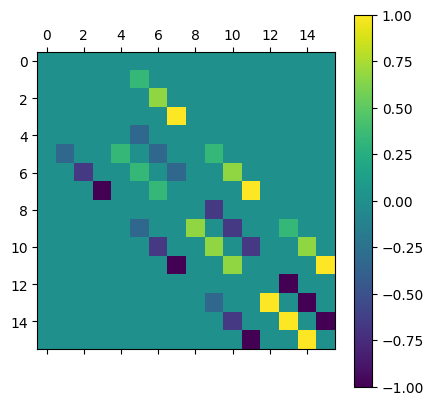

In [84]:
P = -1j * diags([np.ones(n), -np.ones(n)], offsets=[1,-1])

H = kron(diags(p_vals), P) + kron(P, -diags(x_vals))

plt.matshow(H.toarray().imag)
plt.colorbar()
plt.show()

We check that this is embedded in the full Hamiltonian.

In [85]:
PROJ_0 = (IDENTITY + PAULI_Z) / 2
PROJ_1 = (IDENTITY - PAULI_Z) / 2

In [86]:
for i in range(n):

    # In general, the coefficient could also depend on x_1
    operators = []
    for j in range(i):
        operators.append("I")

    if encoding == "unary":
        operators.append("Y")
    else:
        operators.append(str((-1) ** i) + "Y")
    
    for j in range(n-i-1):
        operators.append("I")
    print(operators)
    

['Y', 'I', 'I']
['I', 'Y', 'I']
['I', 'I', 'Y']


In [87]:
# Bitstring where bit i is 1 if we control on it
control_bitstring = np.zeros(n)
control_bitstring[0] = 1
control_bitstring[-1] = 1 

for k in range(n+1):

    # Control on chain for x_2
    control_operators = []

    for l in range(n):

        
        # Unary encoding
        if encoding == "unary":
            if l - k >= 0:
                PROJ = "|0><0|"
            else:
                PROJ = "|1><1|"
        else:
            # AFM encoding
            if k % 2 == 0:
                PROJ = "|0><0|"
            else:
                PROJ = "|1><1|"
        
        if control_bitstring[l] == 1:

            control_operators.append(PROJ)
        else:
            control_operators.append("I")

    
    print(control_bitstring)
    print(control_operators)

    control_bitstring[k-1] = 1 - control_bitstring[k-1]
    control_bitstring[(k+1) % n] = 1 - control_bitstring[(k+1) % n]

[1. 0. 1.]
['|0><0|', 'I', '|0><0|']
[1. 1. 0.]
['|1><1|', '|0><0|', 'I']
[0. 1. 1.]
['I', '|1><1|', '|0><0|']
[1. 0. 1.]
['|1><1|', 'I', '|1><1|']


In [88]:
H_full = csc_matrix((2 ** (2 * n), 2 ** (2 * n)))

# x_2 \partial_{x_1} u
for i in range(n):

    # In general, the coefficient could also depend on x_1
    operators = []
    
    for j in range(n-i-1):
        operators.append(IDENTITY)

    if encoding == "unary":
        operators.append(PAULI_Y)
    else:
        operators.append(((-1) ** i) * PAULI_Y)
    
    for j in range(i):
        operators.append(IDENTITY)

    # Control part

    # Bitstring where bit i is 1 if we control on it
    control_bitstring = np.zeros(n)
    control_bitstring[0] = 1
    control_bitstring[-1] = 1 

    for k in range(n+1):

        # Control on chain for x_2
        control_operators = []

        for l in range(n):
            if encoding == "unary":
                # Unary
                if l - k >= 0:
                    PROJ = PROJ_0
                else:
                    PROJ = PROJ_1
            else:
                if k % 2 == 0:
                    PROJ = PROJ_0
                else:
                    PROJ = PROJ_1
                
            control_operators.insert(0, (1 - control_bitstring[l]) * IDENTITY + control_bitstring[l] * PROJ)

        control_bitstring[k-1] = 1 - control_bitstring[k-1]
        control_bitstring[(k+1) % n] = 1 - control_bitstring[(k+1) % n]

        H_full += kron(tensor(operators), p_vals[k] * tensor(control_operators))

        H_full += kron(-x_vals[k] * tensor(control_operators), tensor(operators))


In [89]:
codewords = get_codewords_2d(n, encoding=encoding)

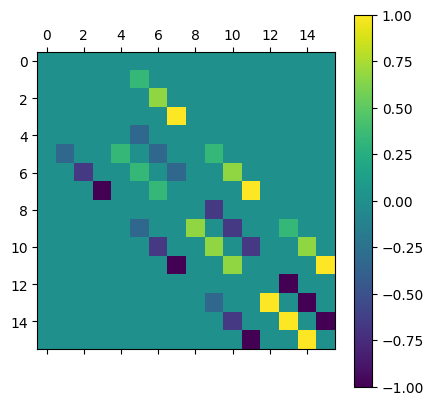

In [90]:
H_subspace = np.zeros((N ** 2, N ** 2), dtype=np.complex64)

for i in range(N ** 2):
    index_1 = bitstring_to_int(codewords[i])

    for j in range(N ** 2):
        index_2 = bitstring_to_int(codewords[j])
        H_subspace[i,j] = H_full[index_1, index_2]

plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

This shows that this method works as predicted.

In general, we can map the spatial derivative terms in the PDE as follows:

$$
\begin{align*}
    f(x_i) \frac{\partial u}{\partial x_i} &\to \frac{1}{2h}\sum_{k=1}^{n} (-1)^{k+1} Y_k^{(i)} f(\hat{q}_k), \newline
    f(x_j) \frac{\partial u}{\partial x_i} &\to \frac{1}{2h}\sum_{\ell=1}^{N} \mathrm{Proj}^{(j)}(\ell) q_{\ell} \sum_{k=1}^{n} (-1)^{k+1} Y_k^{(i)},
\end{align*}
$$
where $Y_k^{(i)}$ denotes the Pauli-$y$ operator on the $k$th qubit for the chain representing $x_i$, and $\mathrm{Proj}^{(j)}(\ell)$ denotes the projector defined as follows:
$$
\begin{align*}
    \mathrm{Proj}^{(j)}(1) &= \ket{0}\bra{0} \otimes I \otimes I \dots \otimes \ket{0}\bra{0}, \\
    \mathrm{Proj}^{(j)}(2) &= \ket{1}\bra{1} \otimes \ket{1}\bra{1} \otimes I \dots \otimes I, \\
    \mathrm{Proj}^{(j)}(3) &= I \otimes \ket{0}\bra{0} \otimes \ket{0}\bra{0} \otimes I \dots \otimes I, \\
    & \enspace \vdots\\
    \mathrm{Proj}^{(j)}(N) &= \ket{1}\bra{1} \otimes I \otimes I \dots \otimes \ket{1}\bra{1}.
\end{align*}
$$,
acting only the qubits in the chain representing $x_j$. This effectively does something like controlled-$Y$, controlling on two qubits.

In theory, we can decompose $-Z_1 Z_2 Y_3 = \frac{[Z_1 X_3, Z_2 Z_3]}{2i}$ using Lemma 7 in https://arxiv.org/abs/2003.06886.

Products with more variables can also be done with more controlled-$Y$. Depending on how complicated the coefficients are (i.e. how sparse the Jacobian of $F(x)$ is), this may require many $Z\otimes Z \otimes Y$ operators.